In [1]:
%pip install ragas


[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt
from datasets import Dataset
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, accuracy_score
from transformers import AutoTokenizer, AutoModel, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback

from dotenv import load_dotenv
import os
load_dotenv()
YOUR_HF_TOKEN = os.getenv("YOUR_HF_TOKEN")

/home/bistreamt/Desktop/master/research 3/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
import json

label_map = {
    "vinovat": 0,
    "nevinovat": 1
}

def prepare_dataset(json_file_path):
    with open(json_file_path, 'r', encoding='utf-8') as f:
        data = json.load(f)
    

    formatted_data = []
    for entry in data:
        entry.pop("source_path", None)
        # Combine description (1-8) and justification (1-4)
        desc = " ".join([entry.get(f"case_description_{i}", "") for i in range(1, 9)]).strip()
        just = " ".join(entry.get(f"sentence", "")).strip()
        sentence = " ".join(entry.get(f"sentence", "")).strip()
        if len(desc) < 5610:
            formatted_data.append({
                "text": f"{desc}", # Description prioritized by order
                "just": f"{just}", # Justification
                "sentence": f"{sentence}", # Sentence prioritized by order
                "label": label_map[entry["label"]]
            })
    
    # Split into train and validation (85/15)
    train_data, val_data = train_test_split(
        formatted_data, 
        test_size=0.0499, 
        stratify=[d["label"] for d in formatted_data], # Keep class ratios same
        random_state=42
    )
    
    return Dataset.from_list(train_data), Dataset.from_list(val_data)

rag_dataset, val_dataset = prepare_dataset("data/regional-court-data.json")

In [9]:
print(f"Rag KB size: {len(rag_dataset)} Validation size: {len(val_dataset)}")
print(f"Type of rag_dataset: {type(rag_dataset)}")
print(f"Type of val_dataset: {type(val_dataset)}")



Rag KB size: 1901 Validation size: 100
Type of rag_dataset: <class 'datasets.arrow_dataset.Dataset'>
Type of val_dataset: <class 'datasets.arrow_dataset.Dataset'>


In [10]:
import numpy as np
import faiss
from sentence_transformers import SentenceTransformer
from datasets import Dataset

# 1. Setup Model (Optimized for Romanian nuances)
# This model is excellent for Romanian and 50+ other languages.
model_name = "sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
embedder = SentenceTransformer(model_name)

def build_rag_system(rag_dataset):
    # 2. Encode the Knowledge Base
    print("Encoding knowledge base...")
    kb_texts = rag_dataset['text']
    kb_embeddings = embedder.encode(kb_texts, convert_to_numpy=True, show_progress_bar=True)
    
    # 3. Initialize FAISS Index
    dimension = kb_embeddings.shape[1]
    index = faiss.IndexFlatL2(dimension)
    index.add(kb_embeddings)
    
    return index, kb_texts, rag_dataset['label']

# Initialize the system
faiss_index, kb_texts, kb_labels = build_rag_system(rag_dataset)

def run_inference(query_text, k):
    # 4. Retrieval
    query_embedding = embedder.encode([query_text], convert_to_numpy=True)
    distances, indices = faiss_index.search(query_embedding, k)
    
    # Get retrieved neighbors
    retrieved_labels = [kb_labels[i] for i in indices[0]]
    retrieved_texts = [kb_texts[i] for i in indices[0]]
    
    # 5. Logic for Label, Confidence, and Explanation
    # We calculate confidence based on label agreement and distance
    label_0_count = retrieved_labels.count(0)
    label_1_count = retrieved_labels.count(1)
    
    predicted_label = 1 if label_1_count >= label_0_count else 0
    
    # Simple confidence score based on retrieval consensus
    consensus = max(label_0_count, label_1_count) / k
    # Soften score based on distance (closer = more confident)
    avg_distance = np.mean(distances[0])
    confidence_score = round(consensus * (1 / (1 + avg_distance * 0.1)), 2)
    
    # Construct Romanian explanation
    explanation = f"Bazat pe cele mai similare {k} exemple găsite: "
    explanation += f"{label_1_count} indică eticheta 1 și {label_0_count} indică eticheta 0. "
    explanation += f"Cel mai apropiat context: '{retrieved_texts[0][:100]}...'"

    return {
        "label": predicted_label,
        "confidence score": confidence_score,
        "explanation": explanation
    }, retrieved_texts, retrieved_labels


Encoding knowledge base...


Batches: 100%|██████████| 60/60 [00:03<00:00, 19.19it/s]


In [5]:
# # 6. Inference over val_dataset
# results = []
# for i in range(len(val_dataset)):
#     sample = val_dataset[i]
#     output = run_inference(sample['text'])
#     count = 0 
#     if output['label'] == sample['label']:
#         count +=1

#     print(count)
    
#     print(f"--- Sample {i} ---")
#     print(f"label: {output['label']}")
#     print(f"confidence score: {output['confidence score']}")
#     print(f"explanation: {output['explanation']}\n")
#     results.append(output)

In [11]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = []
y_pred = []
retrieved_texts_all = []
explanations_all = []

print("Running evaluation...")
for i in range(len(val_dataset)):
    sample = val_dataset[i]
    output, retrieved_texts, retrieved_labels = run_inference(sample['text'], k=3)
    
    y_true.append(sample['label'])
    y_pred.append(output['label'])
    explanations_all.append(output['explanation'])
    retrieved_texts_all.append(retrieved_texts)

# Calculate metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = sum([1 if y_true[i] == y_pred[i] else 0 for i in range(len(y_true))]) / len(y_true) 

print("RESULTS FOR RECALL@3:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Running evaluation...
RESULTS FOR RECALL@3:
Accuracy: 0.8000
F1 Score: 0.7619
Precision: 0.7805
Recall: 0.7442


In [19]:
sample_idx = 0  # change if needed
sample = val_dataset[sample_idx]

query_text = sample["text"]
query_sentence = sample["sentence"]

distances, indices = faiss_index.search(
    embedder.encode([query_text], convert_to_numpy=True),
    3
)

retrieved = []
for rank, idx in enumerate(indices[0], start=1):
    retrieved.append({
        "rank": rank,
        "text": rag_dataset[int(idx)]["text"],
        "sentence": rag_dataset[int(idx)]["sentence"],
        "label": rag_dataset[int(idx)]["label"],
        "distance": float(distances[0][rank - 1])
    })

output, _, _ = run_inference(query_text, k=3)

print("Query sentence:")
print(query_sentence)
print("\nModel explanation:")
print(output["explanation"])

# print("\nTop-3 retrieved entries:")
# for item in retrieved:
#     print(f"\nRank {item['rank']} | label={item['label']} | distance={item['distance']:.4f}")
#     print("Sentence:")
#     print(item["sentence"])

Query sentence:
A - l   r e c u n o a ş t e   v i n o v a t   p e   x x x x N U M E x x x x   d e   s ă v ă r ş i r e a   i n f r a c ţ i u n i i   p r e v ă z u t ă   d e   a r t .   2 0 1 1   a l i n . ( 3 )   l i t .   a )   C o d   p e n a l   ş i   a - i   n u m i   p e d e a p s a   c u   a p l i c a r e a   a r t .   7 9   C o d   p e n a l   3   / t r e i   / a n i   ş i   6 / ş a s e   l u n i   î n c h i s o a r e .   P e d e a p s a   n u m i t ă   u r m e a z ă   a   f i   e x e c u t a t ă   î n   p e n i t e n c i a r   d e   t i p   î n c h i s .   M ă s u r a   p r e v e n t i v ă   i n c u l p a t u l u i   x x x x N U M E x x x x   s e   s c h i m b ă   d e   l a   o b l i g a r e a   d e   a   n u   p ă r ă s i   l o c a l i t a t e a   l a   a r e s t   p r e v e n t i v   p î n ă   l a   î n t r a r e a   î n   v i g o a r e   a   p r e z e n t e i   s e n t i n ţ e ,   l u î n d u - l   s u b   a r e s t   d i n   s a l a   ş e d i n ţ e i   d e   j u d e c a t ă 

In [ ]:
sample_idx = 1  # change if needed
sample = val_dataset[sample_idx]

query_text = sample["text"]
query_sentence = sample["sentence"]

distances, indices = faiss_index.search(
    embedder.encode([query_text], convert_to_numpy=True),
    3
)

retrieved = []
for rank, idx in enumerate(indices[0], start=1):
    retrieved.append({
        "rank": rank,
        "text": rag_dataset[int(idx)]["text"],
        "sentence": rag_dataset[int(idx)]["sentence"],
        "label": rag_dataset[int(idx)]["label"],
        "distance": float(distances[0][rank - 1])
    })

output, _, _ = run_inference(query_text, k=3)

print("Query sentence:")
print(query_sentence)
print("\nModel explanation:")
print(output["explanation"])

# print("\nTop-3 retrieved entries:")
# for item in retrieved:
#     print(f"\nRank {item['rank']} | label={item['label']} | distance={item['distance']:.4f}")
#     print("Sentence:")
#     print(item["sentence"])

Query sentence:
A   î n c e t a   p r o c e s u l u i   p e n a l   î n   c a u z a   l u i   x x x x N U M E x x x x ,   c a r e   a   s ă v î r ș i t   i n f r a c ț i u n e a   p r e v ă z u t ă   î n   a r t . 1 9 2   a l . ( 1 )   C o d   p e n a l ,   î n   l e g ă t u r ă   c u   î m p ă c a r e a   p ă r ţ i l o r .   M ă s u r ă   p r e v e n t i v ă   –   a r e s t u l ,   a p l i c a t ă   f a ţ ă   d e   x x x x N U M E x x x x   d e   a   o   r e v o c a ,   c u   e l i b e r a r e a   l u i   x x x x N U M E x x x x   d e   s u b   a r e s t   d i n   s a l a   d e   j u d e c a t ă .   S e n t i n ţ a ,   p r o n u n ţ a t ă   i n t e g r a l   l a   d a t a   d e   2 5   m a r t i e   2 0 1 5 ,   c u   d r e p t   d e   a t a c   l a   C u r t e a   d e   A p e l   B ă l ţ i   î n   t e r m e n   d e   1 5   z i l e ,   p r i n   i n t e r m e d i u l

Model explanation:
Bazat pe cele mai similare 3 exemple găsite: 2 indică eticheta 1 și 1 indică eticheta 0. Cel mai apr

In [15]:
sample_idx = 2  # change if needed
sample = val_dataset[sample_idx]

query_text = sample["text"]
query_sentence = sample["sentence"]

distances, indices = faiss_index.search(
    embedder.encode([query_text], convert_to_numpy=True),
    3
)

retrieved = []
for rank, idx in enumerate(indices[0], start=1):
    retrieved.append({
        "rank": rank,
        "text": rag_dataset[int(idx)]["text"],
        "sentence": rag_dataset[int(idx)]["sentence"],
        "label": rag_dataset[int(idx)]["label"],
        "distance": float(distances[0][rank - 1])
    })

output, _, _ = run_inference(query_text, k=3)

print("Query sentence:")
print(query_sentence)
print("\nModel explanation:")
print(output["explanation"])

print("\nTop-3 retrieved entries:")
for item in retrieved:
    print(f"\nRank {item['rank']} | label={item['label']} | distance={item['distance']:.4f}")
    print("Sentence:")
    print(item["sentence"])

Query sentence:
S e   a d m i t e   a p e l u l   d e c l a r a t   d e   p r o c u r o r u l   î n   P r o c u r a t u r a   U T A   G ă g ă u z i a ,   s e d i u l   V u l c ă n e ș t i ,   T u r c e a c   A .   S e   c a s e a z ă   s e n t i n ț a

Model explanation:
Bazat pe cele mai similare 3 exemple găsite: 2 indică eticheta 1 și 1 indică eticheta 0. Cel mai apropiat context: 'Elucidând şi constatând starea de lucruri descrisă mai sus, conducându-se de art. 415 alin.(1) pct.2...'

Top-3 retrieved entries:

Rank 1 | label=1 | distance=0.0000
Sentence:
S e   a d m i t e   a p e l u l   d e c l a r a t   d e   a v o c a t u l   B a r a n   V i c t o r   î n   i n t e r e s e l e   i n c u l p a t u l u i   S e c r i e r u   M i h a i l .   S e   c a s e a z ă   p a r ț i a l   s e n t i n ț a

Rank 2 | label=1 | distance=0.3841
Sentence:
S e   a d m i t   a p e l u r i l e   d e c l a r a t e   d e   p r o c u r o r u l   î n   P r o c u r a t u r a   r a i o n u l u i   C a h u l

In [7]:
# # pip install evaluate rouge_score
# import evaluate

# # Load metrics
# rouge = evaluate.load("rouge")
# bleu = evaluate.load("bleu")

# predictions = []
# references = []

# for i in range(len(val_dataset)):
#     sample = val_dataset[i]
#     output, retrieved_texts, retrieved_labels = run_inference(sample['text'])
    
#     predictions.append(output['explanation'])
#     # Assuming your val_dataset has a field like 'reference_explanation'
#     references.append(sample['just']) 

# # Compute ROUGE (measures recall-oriented overlap)
# rouge_results = rouge.compute(predictions=predictions, references=references)

# # Compute BLEU (measures precision-oriented n-gram overlap)
# bleu_results = bleu.compute(predictions=predictions, references=references)

# print(f"ROUGE-1: {rouge_results['rouge1']:.4f}")
# print(f"ROUGE-L: {rouge_results['rougeL']:.4f}")



In [8]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "ai-forever/mGPT-1.3B-romanian"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

def calculate_perplexity(text):
    inputs = tokenizer(text, return_tensors="pt")
    input_ids = inputs["input_ids"]
    
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
    
    loss = outputs.loss
    return torch.exp(loss).item()

# Example usage on your RAG outputs
ppl_scores = [calculate_perplexity(exp) for exp in explanations_all]

print(f"Average Perplexity: {sum(ppl_scores)/len(ppl_scores):.2f}")

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Average Perplexity: 50.52


In [13]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = []
y_pred = []
retrieved_texts_all = []
explanations_all = []

print("Running evaluation...")
for i in range(len(val_dataset)):
    sample = val_dataset[i]
    output, retrieved_texts, retrieved_labels = run_inference(sample['text'], k=5)
    
    y_true.append(sample['label'])
    y_pred.append(output['label'])
    explanations_all.append(output['explanation'])
    retrieved_texts_all.append(retrieved_texts)

# Calculate metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = sum([1 if y_true[i] == y_pred[i] else 0 for i in range(len(y_true))]) / len(y_true) 

print("RESULTS FOR RECALL@5:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Running evaluation...
RESULTS FOR RECALL@5:
Accuracy: 0.8000
F1 Score: 0.7674
Precision: 0.7674
Recall: 0.7674


In [10]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "ai-forever/mGPT-1.3B-romanian"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

def calculate_perplexity(text):
    inputs = tokenizer(text, return_tensors="pt")
    input_ids = inputs["input_ids"]
    
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
    
    loss = outputs.loss
    return torch.exp(loss).item()

# Example usage on your RAG outputs
ppl_scores = [calculate_perplexity(exp) for exp in explanations_all]

print("RESULTS FOR RECALL@5:")
print(f"Average Perplexity: {sum(ppl_scores)/len(ppl_scores):.2f}")

RESULTS FOR RECALL@5:
Average Perplexity: 51.82


In [14]:
from sklearn.metrics import precision_score, recall_score, f1_score

y_true = []
y_pred = []
retrieved_texts_all = []
explanations_all = []

print("Running evaluation...")
for i in range(len(val_dataset)):
    sample = val_dataset[i]
    output, retrieved_texts, retrieved_labels = run_inference(sample['text'], k=10)
    
    y_true.append(sample['label'])
    y_pred.append(output['label'])
    explanations_all.append(output['explanation'])
    retrieved_texts_all.append(retrieved_texts)

# Calculate metrics
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)
accuracy = sum([1 if y_true[i] == y_pred[i] else 0 for i in range(len(y_true))]) / len(y_true) 

print("RESULTS FOR RECALL@10:")
print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

Running evaluation...
RESULTS FOR RECALL@10:
Accuracy: 0.7600
F1 Score: 0.7391
Precision: 0.6939
Recall: 0.7907


In [12]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer

model_id = "ai-forever/mGPT-1.3B-romanian"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id)

def calculate_perplexity(text):
    inputs = tokenizer(text, return_tensors="pt")
    input_ids = inputs["input_ids"]
    
    with torch.no_grad():
        outputs = model(input_ids, labels=input_ids)
    
    loss = outputs.loss
    return torch.exp(loss).item()

# Example usage on your RAG outputs
ppl_scores = [calculate_perplexity(exp) for exp in explanations_all]

print("RESULTS FOR RECALL@10:")
print(f"Average Perplexity: {sum(ppl_scores)/len(ppl_scores):.2f}")

RESULTS FOR RECALL@10:
Average Perplexity: 51.61


In [1]:
%pip install graphviz

  Using cached graphviz-0.21-py3-none-any.whl.metadata (12 kB)
Using cached graphviz-0.21-py3-none-any.whl (47 kB)

[notice] A new release of pip is available: 25.3 -> 26.0
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


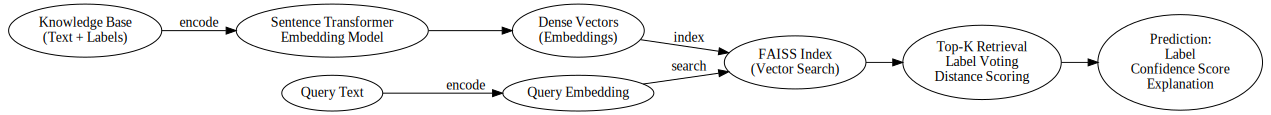

In [9]:
from graphviz import Digraph

def draw_rag_pipeline():
    dot = Digraph(format="png")
    dot.attr(rankdir="LR", size="100")

    # Nodes
    dot.node("D", "Knowledge Base\n(Text + Labels)")
    dot.node("E", "Sentence Transformer\nEmbedding Model")
    dot.node("V", "Dense Vectors\n(Embeddings)")
    dot.node("F", "FAISS Index\n(Vector Search)")
    dot.node("Q", "Query Text")
    dot.node("QE", "Query Embedding")
    dot.node("R", "Top-K Retrieval\n Label Voting\n Distance Scoring")
    # dot.node("A", "Label Voting\n+ Distance Scoring")
    dot.node("O", "Prediction:\nLabel\n Confidence Score\n Explanation\n")

    # Edges
    dot.edge("D", "E", label="encode")
    dot.edge("E", "V")
    dot.edge("V", "F", label="index")

    dot.edge("Q", "QE", label="encode")
    dot.edge("QE", "F", label="search")
    dot.edge("F", "R")
    dot.edge("R", "O")

    return dot

# Generate diagram
diagram = draw_rag_pipeline()
diagram.render("rag_pipeline", cleanup=True)
diagram
